# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# mount
from google.colab import drive
drive.mount('/content/drive')

# read the data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MIT/foodhub_order.csv')
# returns the first 5 rows
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [ ]:
# Write your code here to read the data
# Read the data from the Google Drive
foodOrder = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MIT/foodhub_order.csv') ## Read the foodhub_order file

#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

#starting the work

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here

foodOrder.shape
print( foodOrder.shape[0], 'rows and', foodOrder.shape[1], "columns.")

1898 rows and 9 columns.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Use info() to print a concise summary of the DataFrame
foodOrder.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


Observations:
Dataset
* data relates to the atributes related to customer's restaurant orders    
* contains 9 columns and all are non-null columns
* 5 columns are numeric datatypes and other 4 are object datatypes.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# any missing values in the data
print('Missing values in each column:')
print(foodOrder.isnull().sum())

Missing values in each column:
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


In [ ]:
foodOrder['rating'].value_counts() #


,count
rating,
Not given,736
5,588
4,386
3,188


Observations:
As expected - as the columns are defined as not null, no missing values
rating column had ratings or 'Not given' value



### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Statistical Summary, Min, Avg & Max time
print('Minimum Food prep time :', foodOrder['food_preparation_time'].min())
print('Average Food Prep time :', round(foodOrder['food_preparation_time'].mean(), 2))
print('Maximum Food Prep time :', foodOrder['food_preparation_time'].max())
foodOrder['food_preparation_time'].describe()


Minimum Food prep time : 20
Average Food Prep time : 27.37
Maximum Food Prep time : 35


,food_preparation_time
count,1898.000000
mean,27.371970
std,4.632481
min,20.000000
25%,23.000000
50%,27.000000
75%,31.000000
max,35.000000


Observations:
1. Customers on an average wait around 27 minutes for food preparation.
2. 50% of all orders finish between 23 and 31 minutes. No outliers. The process is consistent, with no extreme delays.
3. Mean and Median are almost identical, the distribution is not heavily skewed.
4. The quartiles are evenly spaced - roughly normal distribution.





### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# order ratings
print(foodOrder['rating'].value_counts())
print('Number of orders NOT rated:', foodOrder[foodOrder['rating'] == 'Not given'].shape[0])

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64
Number of orders NOT rated: 736


#### Observations: Number of orders not rated  by customers  = 736


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]



===== COST_OF_THE_ORDER =====
count    1898.000000
mean       16.498851
std         7.483812
min         4.470000
25%        12.080000
50%        14.140000
75%        22.297500
max        35.410000
Name: cost_of_the_order, dtype: float64


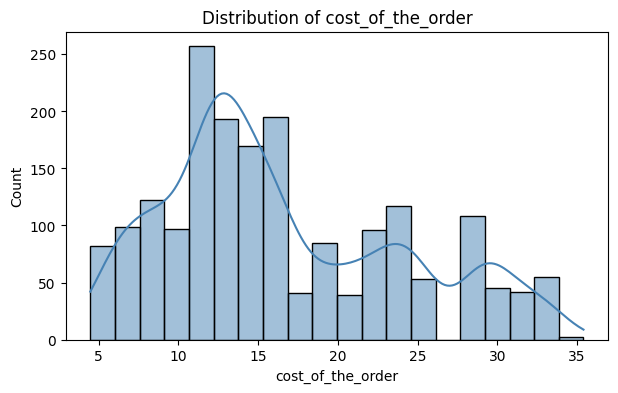

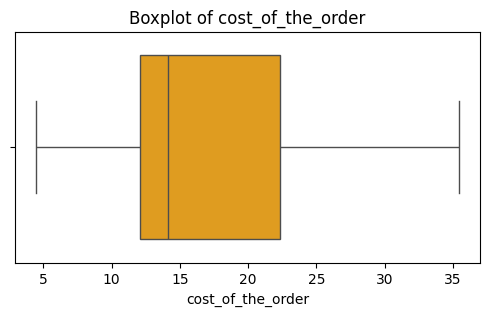



===== FOOD_PREPARATION_TIME =====
count    1898.000000
mean       27.371970
std         4.632481
min        20.000000
25%        23.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: food_preparation_time, dtype: float64


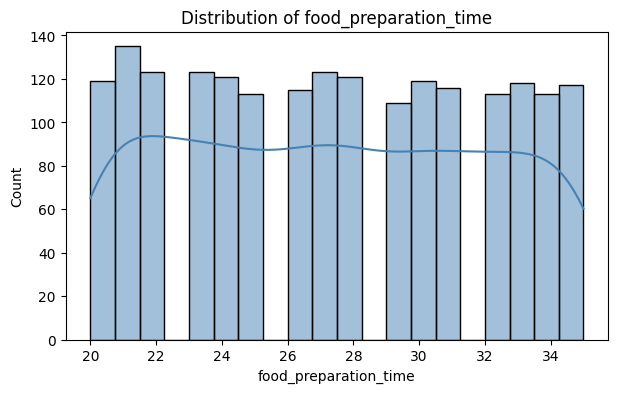

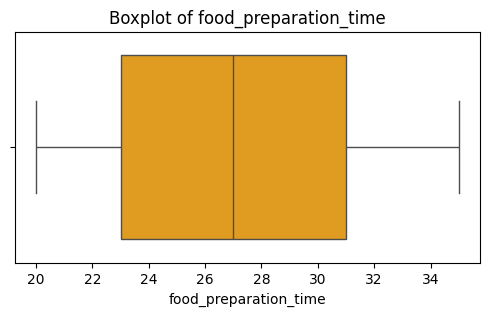



===== DELIVERY_TIME =====
count    1898.000000
mean       24.161749
std         4.972637
min        15.000000
25%        20.000000
50%        25.000000
75%        28.000000
max        33.000000
Name: delivery_time, dtype: float64


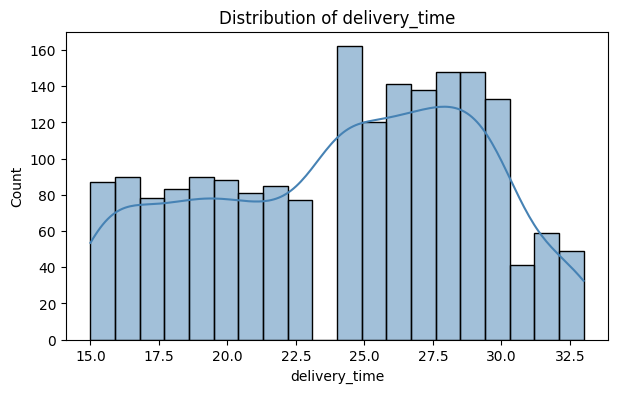

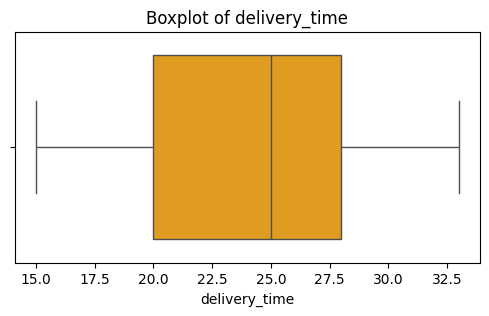

In [ ]:
# Univariate Variables
# Quantitative  - order_id , customer_id , cost_of_the_order, food_preparation_time, delivery_time
# Categorical  - 'restaurant_name', 'cuisine_type', 'day_of_the_week', 'rating'

num_cols = [ 'cost_of_the_order',
            'food_preparation_time', 'delivery_time']

for col in num_cols:
    print(f"\n\n===== {col.upper()} =====")
    print(df[col].describe())

    # Histogram
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=20, color='steelblue')
    plt.title(f"Distribution of {col}")
    plt.show()

    # Boxplot
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
#---- ORDER ID ----
print('Unique Order IDs:', foodOrder['order_id'].nunique())

# ---- CUSTOMER ID ----
print('Unique Customer IDs:', foodOrder['customer_id'].nunique())

# ---- RESTAURANT NAME ----
print('Unique Restaurants:', foodOrder['restaurant_name'].nunique())

# ---- CUISINE TYPE ----
print('Unique Cuisine Types:', foodOrder['cuisine_type'].nunique())

print(foodOrder['cuisine_type'].value_counts()) # count of various Cuisine type restaurants

Unique Order IDs: 1898
Unique Customer IDs: 1200
Unique Restaurants: 178
Unique Cuisine Types: 14
cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64


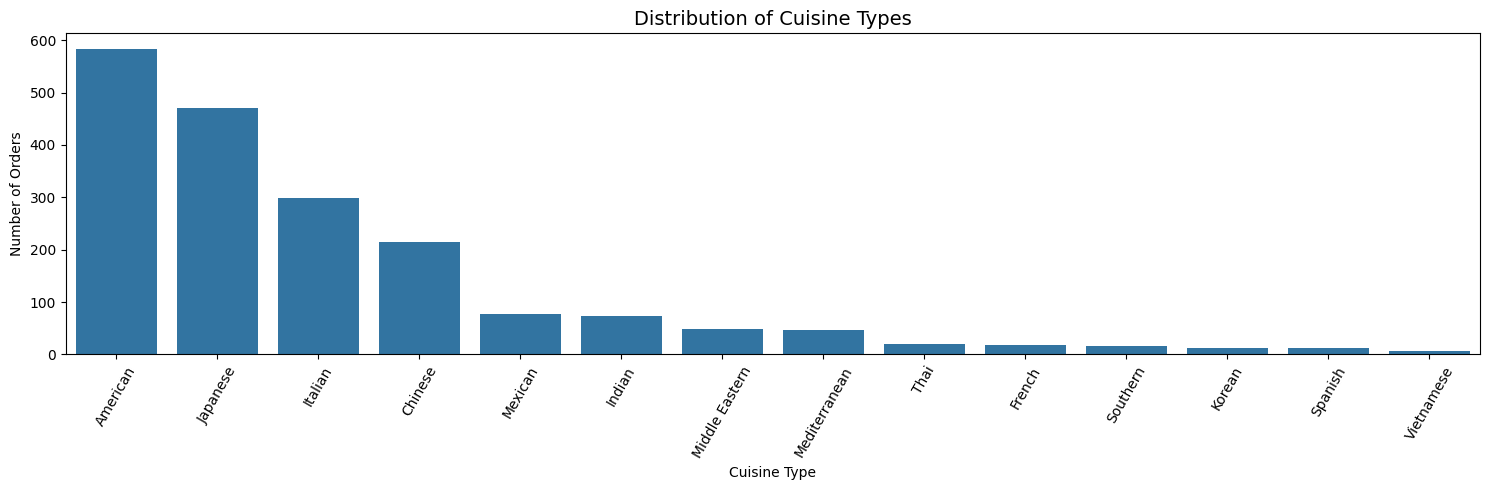

In [ ]:
# Cuisine Type Vs Orders
# Countplot
plt.figure(figsize=(15, 5))
sns.countplot(data=foodOrder, x='cuisine_type', order=foodOrder['cuisine_type'].value_counts().index) #Create a count plot to show the number of orders for each cuisine type
plt.title('Distribution of Cuisine Types', fontsize=14) # Title for the plot
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

Unique values in day_of_the_week: ['Weekend' 'Weekday']
day_of_the_week
Weekend    1351
Weekday     547
Name: count, dtype: int64


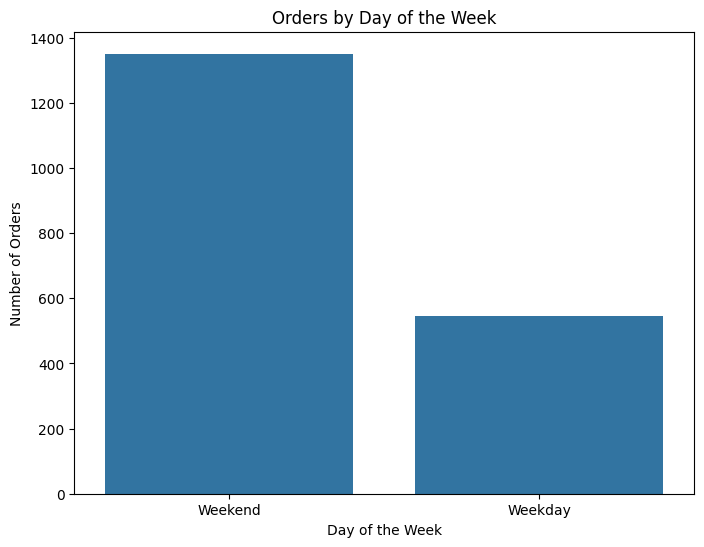

In [ ]:
# Countplot to display Orders by day of the week
print('Unique values in day_of_the_week:', foodOrder['day_of_the_week'].unique())
print(foodOrder['day_of_the_week'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(data=foodOrder, x='day_of_the_week')
plt.title('Orders by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.show()

Unique values in rating: ['Not given' '5' '3' '4']


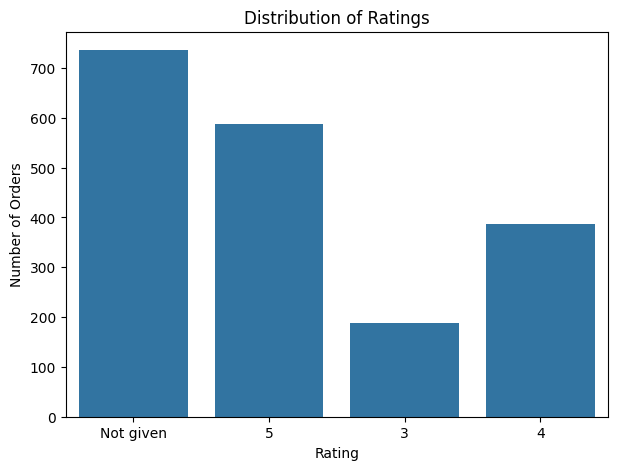

In [ ]:
# Distribution of rating and count of orders
print('Unique values in rating:', foodOrder['rating'].unique())

plt.figure(figsize=(7, 5))
sns.countplot(data=foodOrder, x='rating')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')
plt.show()

**Observations:**
**1. Cost of an order** -
a. Mean = 16.50, Median = 14.14  
Most orders cost around $14–$16, which suggests customers tend to order affordable, single‑meal items rather than large group orders.
b.Distribution Is Right‑Skewed. 75th percentile jumps to 22.30. Maximum is 35.41.
c.Most orders are inexpensive, but premium orders exist.
**2. Delivery Time  -**
a.Mean = 24.16 minutes, Median = 25 minutes  
This shows that the typical delivery time is about 24–25 minutes, Distribution is slightly left‑skewed. Lower tail extends to 15 minutes. Upper tail only reaches 33 minutes

3. Cusine Type
82% of all orders come from just 4 cuisines. Customer preferences are highly concentrated. American and Japanese food alone make up 55% of all orders.

Cuisine	Count	Share
American	584	30.8%
Japanese	470	24.8%
Italian	298	15.7%
Chinese	215	11.3%

**4.Orders **
71% of all orders happen on weekends, while only 29% occur on weekdays.

**5.Ratings**
Not Given is the highest category, followed by 5.



### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

Top 5 Restaurants by Number of Orders:
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


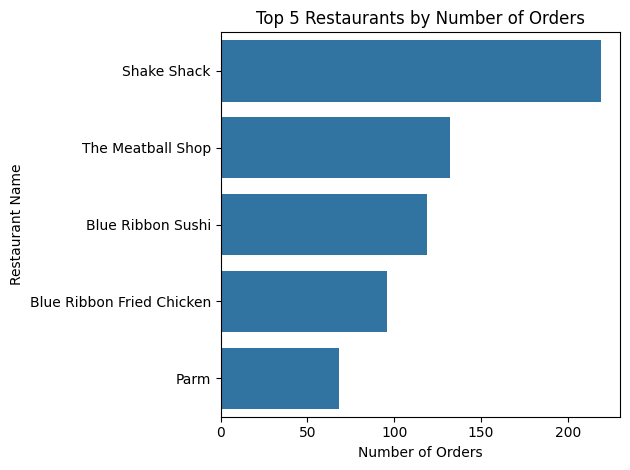

In [ ]:
# # Get top 5 restaurants with highest number of orders
top5_restaurants = foodOrder['restaurant_name'].value_counts().head(5)
print('Top 5 Restaurants by Number of Orders:')
print(top5_restaurants)

# barplot
sns.barplot(x=top5_restaurants.values, y=top5_restaurants.index)
plt.title('Top 5 Restaurants by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Restaurant Name')
plt.tight_layout()
plt.show()

#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
#most popular cuisine on weekend
foodOrder_weekend = foodOrder[foodOrder['day_of_the_week'] == 'Weekend'] # Filter weekend orders

# Most popular cuisine on weekends
print('Most popular cuisines on Weekends:')
print(foodOrder_weekend['cuisine_type'].value_counts())



Most popular cuisines on Weekends:
cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Middle Eastern     32
Mediterranean      32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64


 Observations:
 Most popular cuisine  on the weekend is American - 415 orders. 2nd place is Japanese  with 335 food orders and 3rd place is Italian with 207 orders



### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Cost of order > $20
above20_Orders = foodOrder[foodOrder['cost_of_the_order'] > 20]
above20_Orders_percentage = above20_Orders / foodOrder['cost_of_the_order']
print('The number of total orders that cost > $20 dollars :', above20_Orders.shape[0])

above20_Orders_percentage = (above20_Orders.shape[0] / foodOrder.shape[0]) * 100 # percentage of orders
print(above20_Orders_percentage)
print("Percentage of orders > $20 :", round(above20_Orders_percentage, 2), '%') # round to 2 decimal places

The number of total orders that cost > $20 dollars : 555
29.24130663856691
Percentage of orders > $20 : 29.24 %


Observations: 29.24 % of the food orders cost more than $20.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Mean - order delivery time
mean_delivery_time = foodOrder['delivery_time'].mean()
print("The mean order delivery time :", round(mean_delivery_time, 2), "minutes")

The mean order delivery time : 24.16 minutes


Observations:
Mean Order Delivery time  = 24.2 Minutes


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Top 3 frequent customers
frequent_customers = foodOrder['customer_id'].value_counts().head(3)
print(frequent_customers)

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


Observations:
Top 3 customers - customer Id (number of orders)
52832    (13)
47440    (10)
83287     (9)




### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


Cuisine Type Vs Food Prep Time

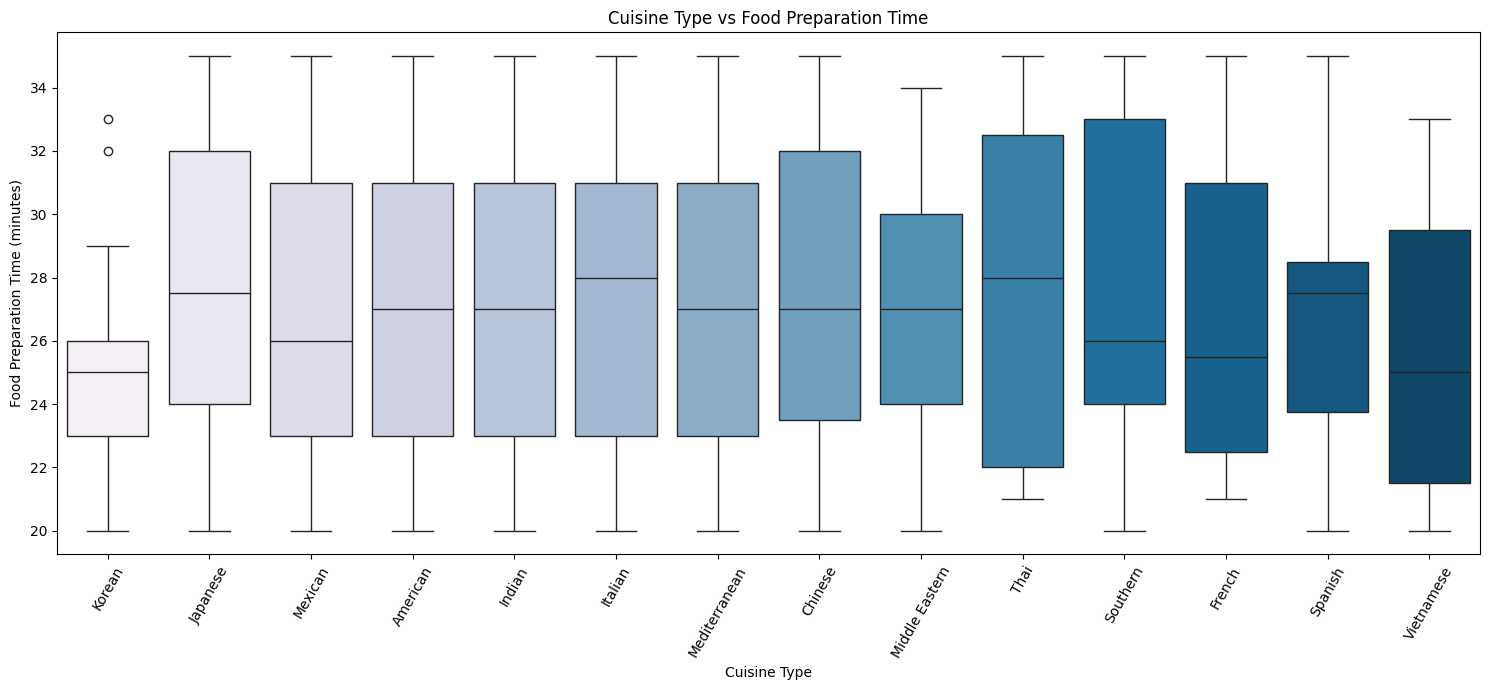

In [ ]:
#Cuisine Type vs Food Prep Time ----
plt.figure(figsize=(15, 7))
sns.boxplot(x='cuisine_type', y='food_preparation_time', data=foodOrder, palette='PuBu', hue='cuisine_type')
plt.title('Cuisine Type vs Food Preparation Time')
plt.xlabel('Cuisine Type')
plt.ylabel('Food Preparation Time (minutes)')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

Rating Vs Food prep Time

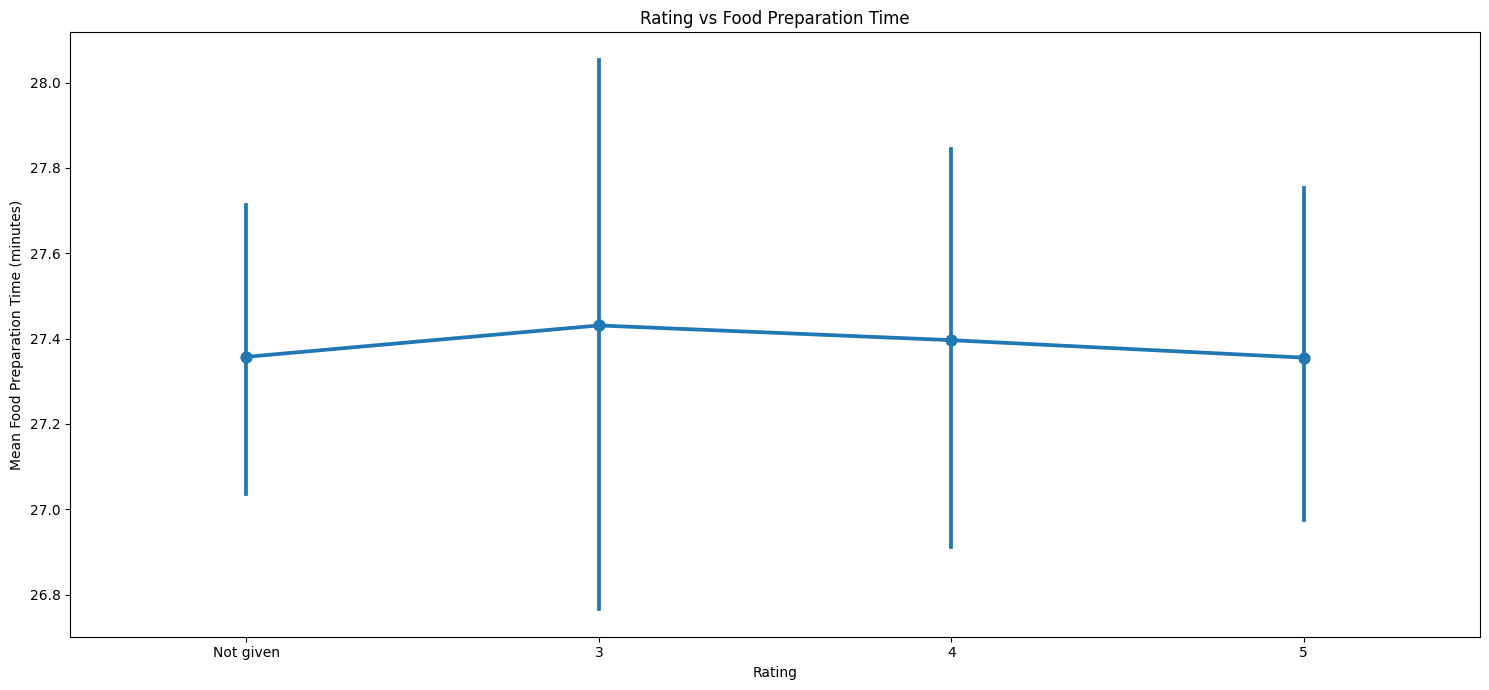

In [ ]:
#Rating vs Food Preparation Time ----
plt.figure(figsize=(15, 7))
sns.pointplot(x='rating', y='food_preparation_time', data=foodOrder, order=['Not given', '3', '4', '5'])
plt.title('Rating vs Food Preparation Time')
plt.xlabel('Rating')
plt.ylabel('Mean Food Preparation Time (minutes)')
plt.tight_layout()
plt.show()

**Cost of the order vs rating**

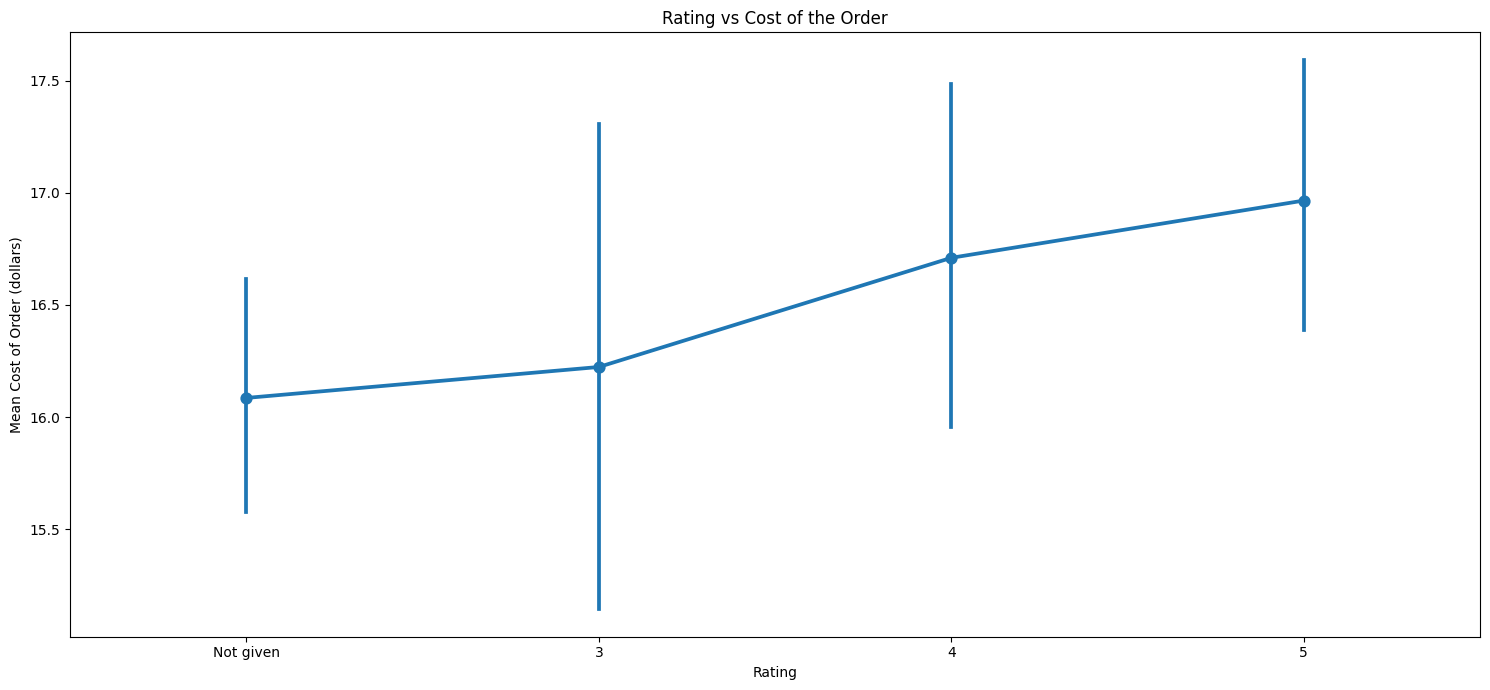

In [ ]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='rating', y='cost_of_the_order', data=foodOrder, order=['Not given', '3', '4', '5'])
plt.title('Rating vs Cost of the Order')
plt.xlabel('Rating')
plt.ylabel('Mean Cost of Order (dollars)')
plt.tight_layout()
plt.show()

**Cuisine Type vs Cost of the Order **

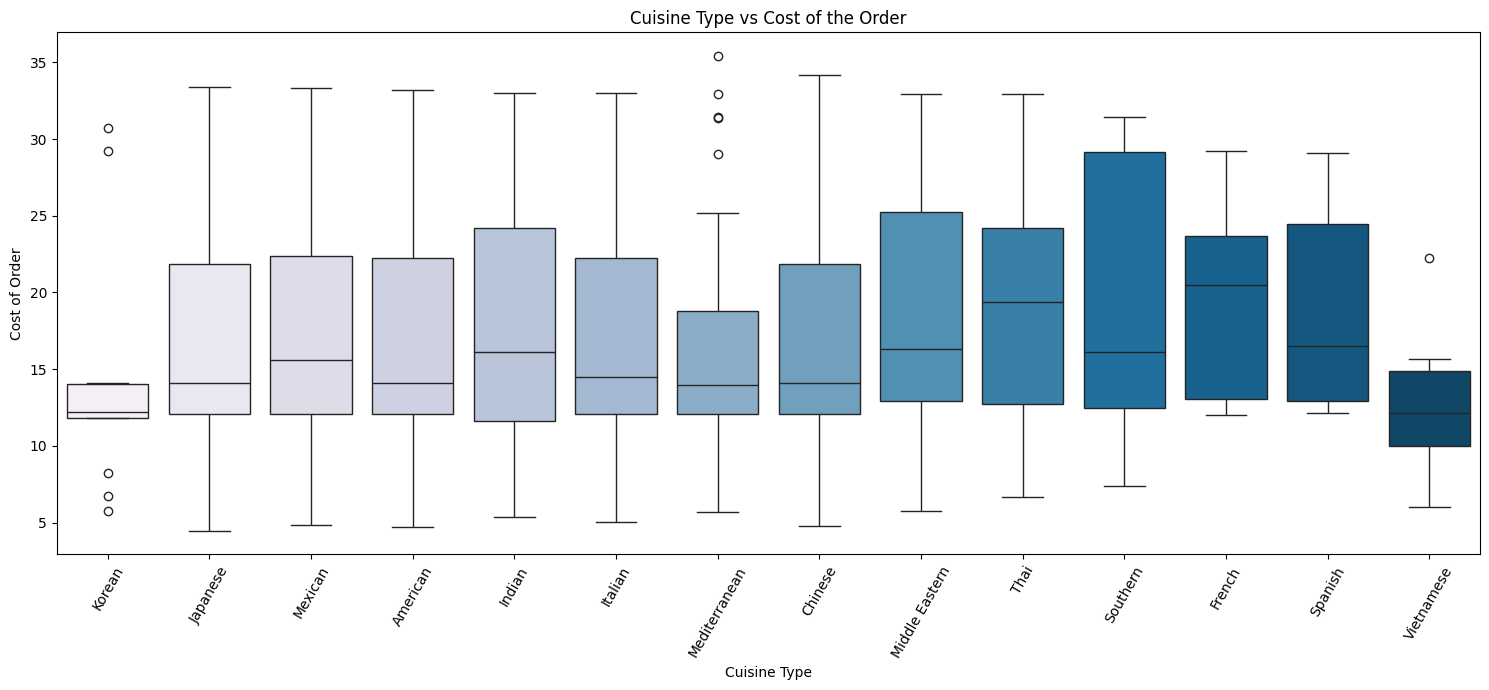

In [ ]:
# Cuisine Type vs Cost of the Order ----
plt.figure(figsize=(15, 7))
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=foodOrder, palette='PuBu', hue='cuisine_type')
plt.title('Cuisine Type vs Cost of the Order')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of Order')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

Day of week Vs Delivery time

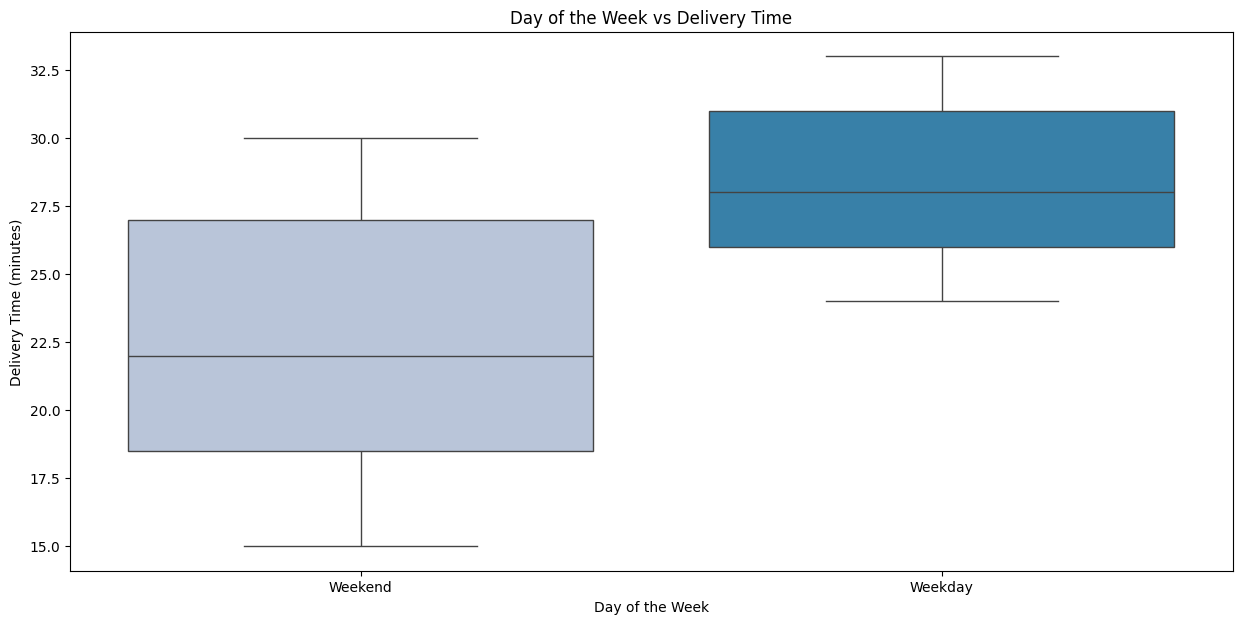

In [ ]:
#Day of the Week vs Delivery Time
plt.figure(figsize=(15, 7))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=foodOrder, palette='PuBu', hue='day_of_the_week')
plt.title('Day of the Week vs Delivery Time')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')
plt.show()



> Restaurant Vs Cost of order




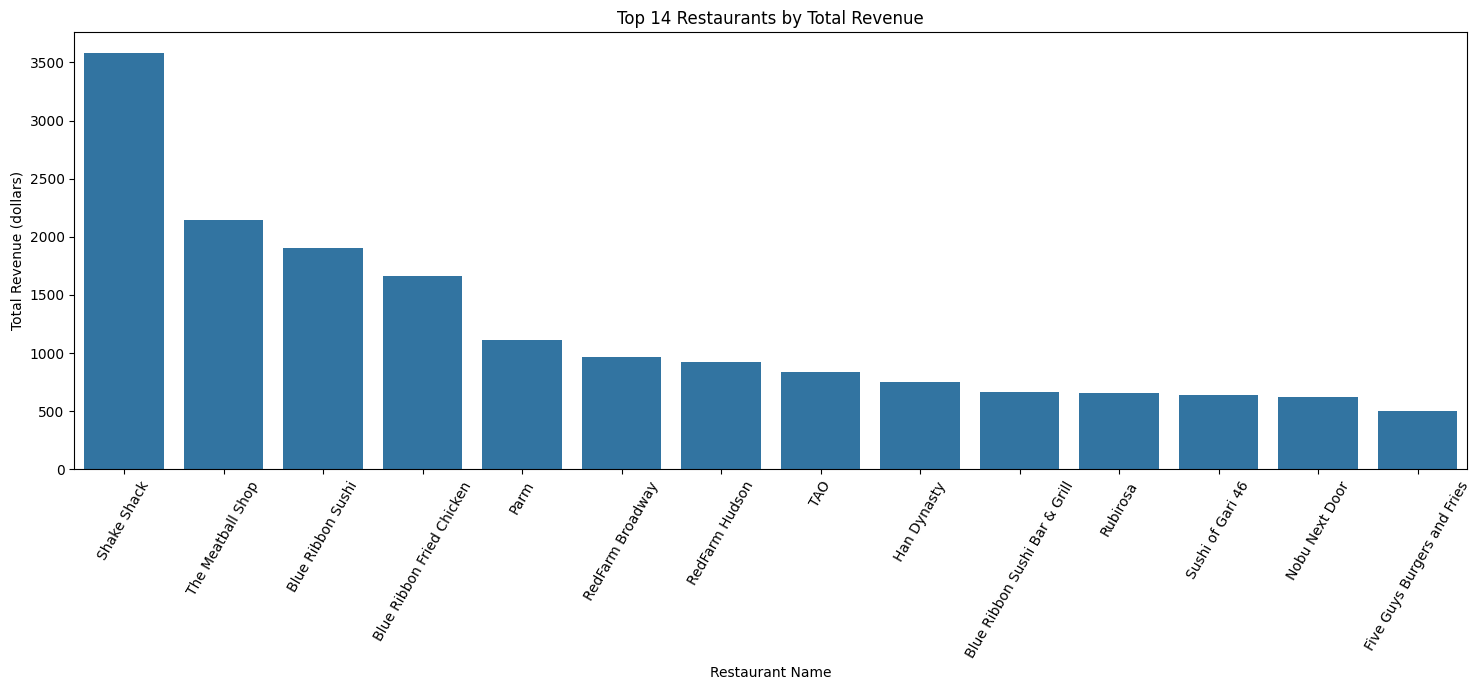

In [ ]:
foodOrder_top14 = (foodOrder.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending=False).head(14))
plt.figure(figsize=(15, 7))
sns.barplot(x=foodOrder_top14.index,
            y=foodOrder_top14.values,
            )
plt.title('Top 14 Restaurants by Total Revenue')
plt.xlabel('Restaurant Name')
plt.ylabel('Total Revenue (dollars)')
plt.xticks(rotation=60)   # rotate names
plt.tight_layout()
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Filter out rows where rating is 'Not given' to calculate a cumulative count and average.
foodOrder_rated = foodOrder[foodOrder['rating'] != 'Not given'].copy() # create a copy of the dataset

# Convert rating column to numeric
foodOrder_rated['rating'] = foodOrder_rated['rating'].astype(int)

# Group by restaurant name and calculate both count and mean rating
restaurant_agg_data = foodOrder_rated.groupby('restaurant_name')['rating'].agg(
    rating_count='count',
    avg_rating='mean'
).reset_index()

# Filter restaurants data based on conditions where rating count > 50 and average rating > 4
eligible_restaurants = restaurant_agg_data[
    (restaurant_agg_data['rating_count'] > 50) &
    (restaurant_agg_data['avg_rating'] > 4)
].sort_values(by='avg_rating', ascending=False).reset_index(drop=True)

# Print the output
print(round(eligible_restaurants,2))

             restaurant_name  rating_count  avg_rating
0          The Meatball Shop            84        4.51
1  Blue Ribbon Fried Chicken            64        4.33
2                Shake Shack           133        4.28
3          Blue Ribbon Sushi            73        4.22


#### Observations:
4 restaurants qualified for the promotional offer meeting both the criteria of rating count and rating score.
restaurant_name                   rating_count  avg_rating
The Meatball Shop                    84         4.51
Blue Ribbon Fried Chicken            64         4.33
Shake Shack                          133        4.28
Blue Ribbon Sushi                    73         4.22



### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# calculation - charge based on cost of order
def calculate_charge(x):
  if x > 20:
    return x*0.25
  elif x > 5:
    return x*0.15
  else:
    return 0

# calculate the charge for each order
foodOrder['Revenue'] = foodOrder['cost_of_the_order'].apply(calculate_charge)

# Get total revenue and round it to 2 decimals
total_revenue = round(foodOrder['Revenue'].sum(),2)
print('Net revenue: ', total_revenue, 'dollars')


Net revenue:  6166.3 dollars


Observations: Net revenue generated by the company across all orders  - $6166.3


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# total delivery time = food preparation time + delivery time
foodOrder['total_delivery_time'] = foodOrder['food_preparation_time'] + foodOrder['delivery_time']

# orders taking > 60 mins
foodOrder_greater_than_60 = foodOrder[foodOrder['total_delivery_time'] > 60]

# Determine the % : (Orders taking more than 60 mins/total # of orders)*100
foodOrder_percentage_60 = (foodOrder_greater_than_60.shape[0] / foodOrder.shape[0]) * 100

print('% of orders > 60 mins:', round(foodOrder_percentage_60, 2), '%')
print(foodOrder['total_delivery_time'].describe())

% of orders > 60 mins: 10.54 %
count    1898.000000
mean       51.533720
std         6.833603
min        35.000000
25%        47.000000
50%        52.000000
75%        56.000000
max        68.000000
Name: total_delivery_time, dtype: float64


Observations:
% of orders > 60 mins  = 10.5%


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Mean delivery time on weekdays
foodOrder_weekday_mean = round(foodOrder[foodOrder['day_of_the_week'] == 'Weekday']['delivery_time'].mean(), 2)

# Mean delivery time on weekends
foodOrder_weekend_mean = round(foodOrder[foodOrder['day_of_the_week'] == 'Weekend']['delivery_time'].mean(), 2)

print('The mean delivery time on weekday is ', foodOrder_weekday_mean, 'minutes Vs weekend ', foodOrder_weekend_mean, 'minutes')

print('weekday takes', round(foodOrder_weekday_mean - foodOrder_weekend_mean, 2), 'minutes longer on weekdays')

The mean delivery time on weekday is  28.34 minutes Vs weekend  22.47 minutes
weekday takes 5.87 minutes longer on weekdays


Observations:
The delivery time is different for weekdays and weekends.
Weekday  - 28.3 mins and weekend is 22.5 mins. The difference is 5.9mins. Weekday delivery is longer than weekend by 5.9 mins probably of busy traffic, though number of order over weekends is higher than weekday.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

Conclusions:
The dataset contains 1898 orders from 1200 unique customers across 178 restaurants with 14 cuisine types.

38.78% of orders are unrated (736 orders), there are no 1 or 2 star ratings exist.

High demand on weekends Weekend orders (1351) vs weekday orders (547).

Weekday deliveries takes 5.87 minutes longer than weekend deliveries.

Around 10.54% of orders (200) take more than 60 minutes, which could affect customer satisfaction.

The net revenue is $6,166.30 across all 1898 orders.

Only 4 restaurants qualify for the promotional offer: The Meatball Shop, Blue Ribbon Fried Chicken, Shake Shack, and Blue Ribbon Sushi.

American, Japanese and Italian cuisines are the most popular top 3 rated.

Shake Shack is the most ordered restaurant (219 orders) - many customers like the food.

Recommendations:

  

### Recommendations:

1. Customer Loyalty and Satisfaction -
  a. Improve Order Delivery times
    i) exceeding 60 minutes: 10.54% of orders take over 60 minutes. FoodHub should work with restaurants to improve the total delivery time and increase customer satisfaction
    ii) Weekday deliveries take ~6 minutes longer than weekends. Adding more delivery resources can help to reduce the delivery times on weekdays.
  b.Customer Promotions -  Increase weekday demand. With only 547 weekday orders vs 1351 weekend orders, FoodHub needs to provide some promotions during the weekdays.
  c.Reward loyal customers: The top 3 customers placed 13, 10, and 9 orders respectively. Add more incentives or reward programs for repeat customers. Send personalized recommendations based on previous order history.
  d.Rating Data gathering -  38.8 % of orders have no rating, collecting that data would help to improve the services. FoodHub should introduce or encourage customers to submit ratings with some promotions like discounts on next order.

2.Commissions : Foodhub charges 25% commissions on orders more than 20 dollars. Need to introduce bundle packages, add-ons so that the total price of the order more than $20. Rework the commission strategy.

3. Restaurant offerings  - American, Japanese and Italian cuisine is popular. Provide more menu options for these 3 cuisines.



---